# Poisson Processes

This is a model type that describes events that occur at random intervals. Let's model goal scoring in soccer as an example. 

## The World Cup Problem

In 2018, France defeated Croatia 4 to 2. Based on this info:

- How confident should we be that France is the better team?
- If the same teams played again, what is the chance France would win again?

To answer these questions, we'll have to make some modeling decisions:

- For any team playing another team, there is some unknown goal-scoring rate.
- A goal is equally likely to be scored during any minute of a game. This gives us rate/90 minutes.
- Assume a team never scores twice during the same minute. 

If the number of goals scored in a game follows a Poisson Distribution with goal rate λ, the probability of scoring k goals is:

$$ λ^k \; exp (-λ)\, / \, k! $$

for any non-negative value of k. 

In [1]:
# use scipy tool to model the Poisson distribution 
import scipy.stats
from scipy.stats import poisson

lam = 1.4
dist = poisson(lam)
type(dist)

scipy.stats._distn_infrastructure.rv_frozen

# gives a 'frozen' random variable and provides PMF of the poisson 

scipy.stats._distn_infrastructure.rv_frozen

In [2]:
k = 4
dist.pmf(k)

np.float64(0.039471954028253146)

This implies that if the average goal-scoring rate is 1.4 goals per game, the probability of scoring 4 goals in a game is about 4%. 

In [3]:
# make a PMF to represent the Poisson distribution
from empiricaldist import Pmf

def make_poisson_pmf(lam, qs):
    ps = poisson(lam).pmf(qs)
    pmf = Pmf(ps, qs)
    pmf.normalize
    return pmf

In [4]:
import numpy as np

lam = 1.4
goals = np.arange(10)
pmf_goals = make_poisson_pmf(lam, goals) 

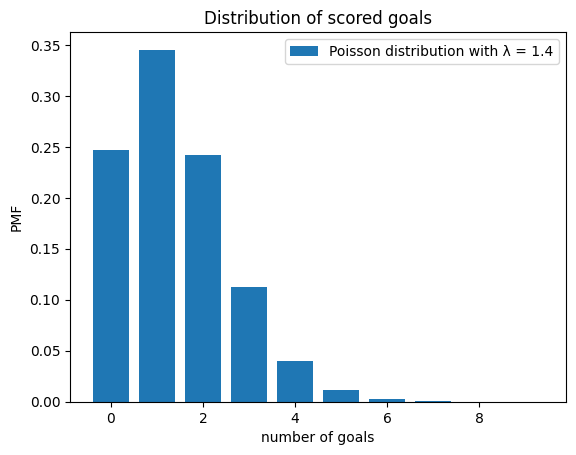

In [5]:
import matplotlib.pyplot as plt

pmf_goals.bar(label = 'Poisson distribution with λ = 1.4')
plt.xlabel('number of goals')
plt.ylabel('PMF')
plt.title('Distribution of scored goals')
plt.legend()
plt.show()

## Gamma Distribution

In [15]:
# set up prior for analysis

from scipy.stats import gamma

alpha = 1.4
qs = np.linspace(0, 10, 101)
ps = gamma(alpha).pdf(qs)

In [16]:
from empiricaldist import Pmf

prior = Pmf(ps, qs)
prior.normalize()

np.float64(9.889360237140306)

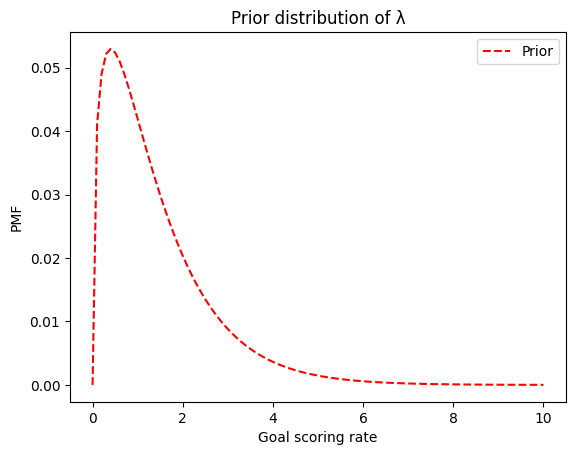

In [17]:
prior.plot(label = 'Prior', linestyle = '--', color = 'red')
plt.xlabel('Goal scoring rate')
plt.ylabel('PMF')
plt.title('Prior distribution of λ')
plt.legend()
plt.show()

## The Update

Earlier we estimated a λ (rate) for goal scoring and then computed the probability of scoring k goals. 

In [21]:
# as an example

lam = 1.4
k = 5
poisson(lam).pmf(5)

np.float64(0.01105214712791088)

Now suppose we have an array of possible values for λ...

We can compute the likelihood of the data of each hypothetical value of lam like this:

In [22]:
lams = prior.qs
k = 4
likelihood = poisson(lams).pmf(k)

Now we have all we need to do the update. To get the posterior, we multiply the prior by the likelihoods we just computed and normalize the result. 

In [25]:
def update_poisson(pmf, data):
    k = data
    lams = pmf.qs
    likelihood = poisson(lams).pmf(k)
    pmf *= likelihood
    pmf.normalize()

In [26]:
france = prior.copy()
update_poisson(france, 4)

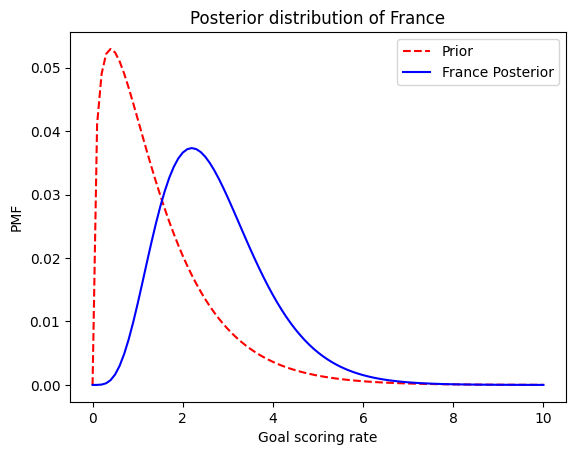

In [29]:
prior.plot(label = 'Prior', linestyle = '--', color = 'red')
france.plot(label = 'France Posterior', linestyle = '-', color = 'blue')
plt.xlabel('Goal scoring rate')
plt.ylabel('PMF')
plt.title('Posterior distribution of France')
plt.legend()
plt.show()

In [31]:
croatia = prior.copy()
update_poisson(croatia, 2)

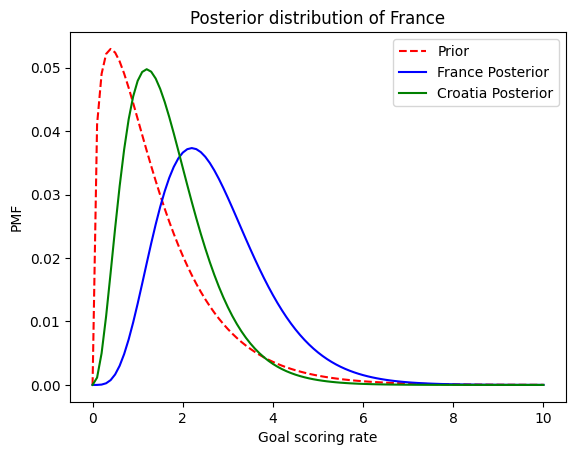

In [32]:
prior.plot(label = 'Prior', linestyle = '--', color = 'red')
france.plot(label = 'France Posterior', linestyle = '-', color = 'blue')
croatia.plot(label = 'Croatia Posterior', linestyle = '-', color = 'green')
plt.xlabel('Goal scoring rate')
plt.ylabel('PMF')
plt.title('Posterior distribution of France')
plt.legend()
plt.show()

In [39]:
moapa = prior.copy()
update_poisson(moapa, 1)

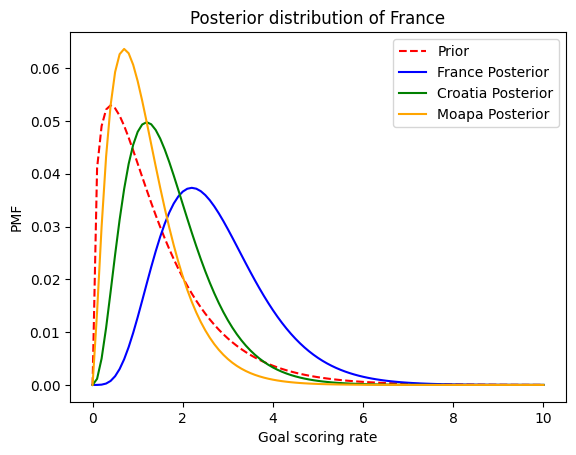

In [40]:
prior.plot(label = 'Prior', linestyle = '--', color = 'red')
france.plot(label = 'France Posterior', linestyle = '-', color = 'blue')
croatia.plot(label = 'Croatia Posterior', linestyle = '-', color = 'green')
moapa.plot(label = 'Moapa Posterior', linestyle = '-', color = 'orange')
plt.xlabel('Goal scoring rate')
plt.ylabel('PMF')
plt.title('Posterior distribution of France')
plt.legend()
plt.show()

In [41]:
print(croatia.mean(), france.mean(), moapa.mean())

1.6999765866755225 2.699772393342308 1.2007250513972962


## Probability of Superiority

Now that we have a posterior distribution for each team, we can answer the first question: How confident should we be that France is a better team? (Meaning they have a higher goal scoring rate.) 

In [42]:
def prob_gt(pmf1, pmf2):
    total = 0
    for q1, p1 in pmf1.items():
        for q2, p2 in pmf2.items():
            if q1 > q2:
                total += p1 * p2
    return total

In [43]:
prob_gt(france, croatia)

0.7499366290930155

In [44]:
# pmf function for the same thing

Pmf.prob_gt(france, croatia)

np.float64(0.7499366290930174)

## Predicting the Rematch

Now we can look at the second question: If the teams played again, what is the chance that Croatia would win? To answer this, we'll generate a "posterior predictive distribution". If we knew the goal scoring rate, the lam, the distribution of the goals would be a Poisson distribution of the parameter lam. Since we don't know lam, the distribution is a mix of Poisson distributions with different values of lam:

In [45]:
pmf_seq = [make_poisson_pmf(lam, goals)
           for lam in prior.qs]